<a href="https://colab.research.google.com/github/ironcevic/basic_stats/blob/main/Hubbard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Good morning! Before we begin, let's recall some maths:

$|a\rangle$ is a basis state.

$|b\rangle$ is another one.

Basis states live in a Hilbert space.

$⟨a|b⟩$ is the overlap (inner product) between $|a⟩$ and $|b⟩$. If we define our states to be orthonormal, we have:

$⟨a|b⟩$ = 0

$⟨a|a⟩$ = $⟨b|b⟩$ = 1

**Problem 1.** Given $|\psi⟩$ = $\frac{|a\rangle + |b\rangle}{\sqrt{2}}$, compute $⟨a|\psi⟩$.

We can move from one basis, $|a⟩$ and $|b⟩$, to another, e.g., $|+⟩$ and $|-⟩$, by using the outer product:

$|a⟩⟨a| = 1$

**Problem 2.** Given $|+⟩ = \frac{|a\rangle + |b\rangle}{\sqrt{2}}$ and $|-\rangle = \frac{|a\rangle - |b\rangle}{\sqrt{2}}$, write $|a⟩$ and $|b⟩$ in terms of $|+⟩$ and $|-⟩$. Both $|a⟩$ and $|b⟩$, and $|+⟩$ and $|-⟩$ are orthonormal.

Hint: $|a⟩ = |+⟩⟨+|a⟩ + |-⟩⟨-|a⟩$.

Now we can start exploring the Hückel model. This is the simplest quantum-chemical model that one can build. It includes electron delocalisation, but not electron-electron repulsion nor spin. In second quantisation, the Hückel Hamiltonian is given by:

$H = - \sum_{i,j\neq i} t_{ij} \ c_i^\dagger c_j + \sum_i n_i \ \epsilon_i$

where

$t_{ij}$ is the coupling between sites $i$ and $j$,

$c_i^\dagger$ creates an electron at site $i$,

$n_i = c_i^\dagger c_i$ counts the number of electrons at site $i$,

$c_j$ destroys an electron at site $j$, and

$\epsilon_i$ is the self-energy of site $i$.

The Hückel Hamiltonian is solved in a Hilbert space defined by one electron and $i$ sites. This is a very small Hilbert space, which we like.

**Problem 3.** Using the code below, solve the Hückel Hamiltonian for a ring of four sites with nearest-neighbour coupling only and $\epsilon_i = 0 $. This may be viewed as a model of the $\mathrm{\pi_z}$-electrons in cyclobutadiene. Plot the MOs. Then, explore the effect of bond length alternation.

Hint: the Hückel matrix elements are given by $H_{ij} = ⟨a_i|H|a_j⟩$.

The basis states are: $|1000⟩, |0100⟩, |0010⟩, |0001⟩$. The $t$ term  moves an electron to the next site, so:

$⟨1000|H|0100⟩ = -t$, as the electron moves by one site, and

$⟨1000|H|0010⟩ = 0$, as an electron moves by two sites.



In [ ]:
# Here is module that will give us symmetry-adapted MOs. Also some imports.
!pip install qutip
import numpy as np
from qutip import *

In [ ]:
t = -1 # we don't really care about the value of t
d = 0.1
# Here is the matrix, now fill it out!
H = np.array([
#  1  2  3  4 site number
  [-2, t+d, 0, t-d], # 1
  [t+d, -2, t-d, 0], # 2
  [0, t-d, -2, t+d], # 3
  [t-d, 0, t+d, -2]  # 4
])
"""
This below is just Qutip stuff.
We could use np.eigh(H) instead,
but Qutip plays nice with symmetry.
"""

Q = Qobj(H)
MO_energies, MO_coefficients = Q.eigenstates()
print("MO energies are:")
print(np.round(np.real(MO_energies), 2))
print("The MOs are:")
for MO in range(len(MO_coefficients)):
    print(f"MO number {MO+1}:")
    print(np.round(np.real(MO_coefficients[MO].full()), 2))

**Problem 4.** Compare the IP (HOMO energy) of benzene and silabenzene, $\mathrm{C_5SiH_6}$.

In [ ]:
t = -1 # we still don't care about the value of t
# Here is a 6x6 matrix
H_benzene = np.array([
#  1  2  3  4  5  6  site number
  [0, t, 0, 0, 0, t], # 1
  [t, 0, t, 0, 0, 0], # 2
  [0, t, 0, t, 0, 0], # 3
  [0, 0, t, 0, t, 0], # 4
  [0, 0, 0, t, 0, t], # 5
  [t, 0, 0, 0, t, 0], # 6
])

H_silabenzene = np.array([
#  1  2  3  4  5  6  site number
  [1, t, 0, 0, 0, t], # 1
  [t, 0, t, 0, 0, 0], # 2
  [0, t, 0, t, 0, 0], # 3
  [0, 0, t, 0, t, 0], # 4
  [0, 0, 0, t, 0, t], # 5
  [t, 0, 0, 0, t, 0], # 6
])
"""
This below is just Qutip stuff.
We could use np.eigh(H) instead,
but Qutip plays nice with symmetry.
"""
# choose your molecule
# H = H_benzene
H = H_silabenzene

Q = Qobj(H)
MO_energies, MO_coefficients = Q.eigenstates()
print("MO energies are:")
print(np.round(np.real(MO_energies), 2))
print("The MOs are:")
for MO in range(len(MO_coefficients)):
    print(f"MO {MO+1} composition:")
    print(np.round(np.real(MO_coefficients[MO].full()), 2))

This is all fine and dandy, but electron–electron interactions are still missing. In the Hückel model, the MOs are fixed and don’t respond to occupancy, which limits it's  quantitative accuracy, but still makes it qualitatively useful.

The Hubbard model is a minimal improvement on top of Hückel: it keeps the same one‑electron hopping but adds an on‑site interaction. In its simplest form,

$H = - \sum_{ij \neq i,s} t_{ij} \ c_{i,s}^\dagger c_{j,s} + \sum_{i,s} n_{i,s} \ \epsilon_i + \sum_i U_i \ n_{i,\uparrow} n_{i, \downarrow} $

where the sums now include spin $s\in\{\uparrow,\downarrow\}$.

A few notes: one, the $U$ term only shifts some diagonal matrix elements, but this subtle change can radically change the ground state. Two, only opposite-spin electrons can occupy the same orbital, so $U$ connects spin and Coulombic repulsion! Three, $U$ can be negative (attractive), for example in superconductivity, demonstrating the ubiquity of the Hubbard model in nature.

The key complication is that electron number now matters. We can’t stay in a one‑electron basis and we must work in the many‑electron basis instead. The size of this basis grows exponentially with the size of the system. Let’s look at a few simple examples.

**Problem 5.** Using the code below, construct a Hubbard Hamiltonian of a dimer with two sites and two electrons. This could represent $\mathrm{H}_2$, the $\mathrm{\pi}$-electrons in $\mathrm{C_2H_2}$ (small $U/t$), or two weakly interacting radicals (large $U/t$). Assume $\epsilon_1 = \epsilon_2 = 0$.

**(a)** Identify the electronic states and write them in terms of the basis.

**(b)** Test $U/t = 0.1$ to $10$ and/or $\epsilon_1 \neq \epsilon_2$.  How does the state composition change?

**(c)** Under what conditions can triplet become the ground state? (This is hard.)

In [ ]:
U = 100
t = -1
# Hubbard model, 2 sites and 2 electrons
H = np.array([
# uu ud du 20 02 dd
  [0, 0, 0, 0, 0, 0], # uu
  [0, 0, 0, t, t, 0], # ud
  [0, 0, 0, t, t, 0], # du
  [0, t, t, U, 0, 0], # 20
  [0, t, t, 0, U, 0], # 02
  [0, 0, 0, 0, 0, 0], # dd
])

Q = Qobj(H)
state_energies, state_coefficients = Q.eigenstates()
print("State energies are:")
print(np.round(np.real(state_energies), 2))
print("The states are:")
for state in range(len(state_coefficients)):
    print(f"State {state+1} composition:")
    print(np.round(np.real(state_coefficients[state].full()), 2))


**Problem 6.** Let us now look at a system with three electrons in three orbitals, focussing on the $m_\mathrm{s} = 1/2$ sector.

In [ ]:
U = 1
t = -1
# Hubbard model, 3 sites and 3 electrons
H = np.array([
# uud udu duu 2u0 20u u20 02u u02 0u2
 [ 0 , 0 , 0 , 0 , 0 , t , 0 , t , 0 ], # uud
 [ 0 , 0 , 0 , 0 , t , t , t , t , 0 ], # udu
 [ 0 , 0 , 0 , 0 , t , 0 , t , 0 , 0 ], # duu
 [ 0 , 0 , 0 , U , t , t , 0 , 0 , 0 ], # 2u0
 [ 0 , t , t , t , U , 0 , 0 , 0 , 0 ], # 20u
 [ t , t , 0 , t , 0 , U , 0 , 0 , 0 ], # u20
 [ 0 , t , t , 0 , 0 , 0 , U , 0 , t ], # 02u
 [ t , t , 0 , 0 , 0 , 0 , 0 , U , t ], # u02
 [ 0 , 0 , 0 , 0 , 0 , 0 , t , t , U ]  # 0u2
])

Q = Qobj(H)
state_energies, eigenstates = Q.eigenstates()
print("State energies are:")
print(np.round(np.real(state_energies), 2))
print("The MOs are:")
for state in range(len(eigenstates)):
    print(f"State {state+1} composition:")
    print(np.round(np.real(eigenstates[state].full()), 2))


**(a)** Using the code below, evaluate the spin density of the ground state.

Hint: The spin density at site $i$ is given by

$\rho_i^{\text{spin}} = \langle\psi | (n_{i,\uparrow} - n_{i,\downarrow}) | \psi \rangle$.

It might be useful to expand the wavefunction in terms of basis states $k$ with contributions $c_k$ and work this out algebraically first.

In [ ]:
# Here is the spin density of the basis states.
# Spin_densities[k] gives the spin density of basis state k.
spin_densities = np.array([
  [1, 1, -1],    # uud: up at 0,1 and down at 2
  [1, -1, 1],    # udu: up at 0,2 and down at 1
  [-1, 1, 1],    # duu: up at 1,2 and down at 0
  [0, 1, 0],     # 2u0: doubly occ at 0, up at 1, empty at 2
  [0, 0, 1],     # 20u: doubly occ at 0, empty at 1, up at 2
  [1, 0, 0],     # u20: up at 0, doubly occ at 1, empty at 2
  [0, 0, 1],     # 02u: empty at 0, doubly occ at 1, up at 2
  [1, 0, 0],     # u02: up at 0, empty at 1, doubly occ at 2
  [0, 1, 0]      # 0u2: empty at 0, up at 1, doubly occ at 2
])

# The next line selects the ground electronic state.
state_number = 0
spin_density = np.array([0.0, 0.0, 0.0])
for basis_state in range(len(eigenstates)): # sum over basis states
    c_k = np.real(eigenstates[state_number].full()[basis_state])
    # spin_density += this is where you write the solution

print("The spin density is:")
print(np.round(spin_density, 2))
print("The total spin density is:")
print(np.round(np.sum(spin_density), 2))


**(b)** Using the code below, compute the energy per electron and the vertical detachment energy of the 3-electron 3-site chain. Then transform the chains into rings. What has changed?

In [ ]:
U = 1
t = -1

# Hubbard model, 3 sites and 3 electrons
H_0 = np.array([
# uud udu duu 2u0 20u u20 02u u02 0u2
 [ 0 , 0 , 0 , 0 , 0 , t , 0 , t , 0 ], # uud
 [ 0 , 0 , 0 , 0 , t , t , t , t , 0 ], # udu
 [ 0 , 0 , 0 , 0 , t , 0 , t , 0 , 0 ], # duu
 [ 0 , 0 , 0 , U , t , t , 0 , 0 , 0 ], # 2u0
 [ 0 , t , t , t , U , 0 , 0 , 0 , 0 ], # 20u
 [ t , t , 0 , t , 0 , U , 0 , 0 , 0 ], # u20
 [ 0 , t , t , 0 , 0 , 0 , U , 0 , t ], # 02u
 [ t , t , 0 , 0 , 0 , 0 , 0 , U , t ], # u02
 [ 0 , 0 , 0 , 0 , 0 , 0 , t , t , U ]  # 0u2
])

# Hubbard model, 3 sites and 2 electrons
H_1 = np.array([
# ud0 u0d 0ud du0 d0u 0du 200 020 002
 [ 0 , t , 0 , 0 , 0 , 0 , t , t , 0 ], # ud0
 [ t , 0 , t , 0 , 0 , 0 , 0 , 0 , 0 ], # u0d
 [ 0 , t , 0 , 0 , 0 , 0 , 0 , t , t ], # 0ud
 [ 0 , 0 , 0 , 0 , t , 0 , t , t , 0 ], # du0
 [ 0 , 0 , 0 , t , 0 , t , 0 , 0 , 0 ], # d0u
 [ 0 , 0 , 0 , 0 , t , 0 , 0 , t , t ], # 0du
 [ t , 0 , 0 , t , 0 , 0 , U , 0 , 0 ], # 200
 [ t , 0 , t , t , 0 , t , 0 , U , 0 ], # 020
 [ 0 , 0 , t , 0 , 0 , t , 0 , 0 , U ]  # 002
])

def diagonalise(H, state_number=0):
    """
    Diagonalises a Hamiltonian.
    input:
    - Hamiltonian matrix (numpy array)
    - chosen state number (integer)
    output:
    - energies of all states (numpy array)
    - coefficients of the chosen state c_k (numpy array)
    """
    Q = Qobj(H)
    energies,  eigenstates = Q.eigenstates()
    c_k = []
    for basis_state in range(len(eigenstates)): # write over basis states
        c_k.append(np.real(eigenstates[state_number].full()[basis_state]))
    c_k = np.array(c_k)
    return energies, c_k

E_0, c_k_0 = diagonalise(H_0)
E_1, c_k_1 = diagonalise(H_1)


**Problem 7.** Now let us consider what happens when two molecules come together. For simplicity we shall work in a spinless basis, using $|1\rangle$ to denote a singly occupied site and restricting ourselves to the singlet manifold.

We shall label molecules 1 and 2, and sites A and B. For a single molecule, we define:  

$\hat{H}|1_\mathrm{A}0_\mathrm{B}⟩ = 0 $

$\hat{H}|2_\mathrm{A}0_\mathrm{B}⟩ = U $

$\hat{H}|0_\mathrm{A}1_\mathrm{B}⟩ = \epsilon $

$\hat{H}|0_\mathrm{A}2_\mathrm{B}⟩ = 2 \epsilon+U $

$\langle1_\mathrm{A}0_\mathrm{B}|\hat{H}|0_\mathrm{A}1_\mathrm{B}⟩ = t_{\mathrm{in}} $

**(a)** Construct and diagonalise the Hamiltonian matrix for this monomer. Discuss the following limits:

$ \epsilon ≃ 0 $

$ \epsilon ≃ U $

$ \epsilon \gg U $

In [ ]:
# Good luck!

**(b)** Given the definition for the transition dipole moment from state a to state b:

$ \mathrm{TDM} = - e \langle \psi_\mathrm{b} | \hat{r} | \psi_\mathrm{a} \rangle$

with

$ \hat{r} = \sum_{i,s} R_i \ c_{i,s}^\dagger c_{i,s}$

work out the rules for maximising optical absorption in the case of a monomer, assuming:

$ R_\mathrm{A} = 0 $

$ R_\mathrm{B} = 1 $

In [ ]:
"""
Good luck! You might be able to re-use some code,
or insights from the spin density calculation.
"""



Now let us consider the dimer, defining:

$\langle1_\mathrm{A}0_\mathrm{B}0_\mathrm{A}0_\mathrm{B}|\hat{H}|0_\mathrm{A}0_\mathrm{B}1_\mathrm{A}0_\mathrm{B}⟩ = \langle1_\mathrm{A}0_\mathrm{B}0_\mathrm{A}0_\mathrm{B}|\hat{H}|0_\mathrm{A}0_\mathrm{B}0_\mathrm{A}1_\mathrm{B}⟩  = t_{\mathrm{nn}} \ll t_{\mathrm{in}}$

**(c)** Write the complete basis for this system. Which basis state has the highest contribution to the ground state for $ \epsilon \gg U $? Rank all basis states relative to this ground state by their excitations.

**(d)** Group excitations as local and charge-transfer.

**(e)** Which matrix elements are zero?

**(f)** Write the matrix! (Yes yes it is about 50 entries and it will take up the whole board.)


**Problem 8. Perturbation theory**

Let us consider the $m_z = 0$ sector of a spinless 4-electron, 3-orbital Hubbard system with two low-energy orbitals and one high-energy orbital. (I appreciate that this might sound _slightly_ overwhelming on a Monday morning after a 3-month break from theory. Nevertheless, we shall proceed.) Some diagonal elements read:

$\langle220|\hat{H}|220\rangle = 2U$

$\langle211|\hat{H}|211\rangle = U + \epsilon$

$\langle022|\hat{H}|022\rangle = 2U + 2\epsilon$

And the off-diagonals are $t$ for single hops, and zero otherwise.

**(a)** Write the Hamiltonian for this system. Then, assume $U \gg t$ and divide it into zero-order and perturbative parts.

**(b)** Solve the zero-order Hamiltonian. Then, using the code below, solve the full Hamiltonian, taking:

$U = 1$

$t= -1$

$\epsilon = 10 $

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
U = 1
t = -1
e = 10

H = np.array([
#  220    211   202    121    112    022
[  ], # 220
[  ], # 211
[  ], # 202
[  ], # 121
[  ], # 112
[  ]  # 022
])

ground_state_energy = np.sort(np.linalg.eigvals(H))[0]
print("The ground state energy is:")
print(np.round(ground_state_energy, 2))

Now we shall determine the ground-state energy using second-order perturbation theory (PT2). In our case, the correction to energy reads:

$$E_{\mathrm{corr}} = \sum_{i} \frac{\langle{\psi_0}|\hat{H}|\psi_i \rangle ^2}{E_i - E_0}$$

Explore the validity of PT2 when:

**(c)** $ \epsilon \gg U $ and $ |t| \ll U$

**(d)** $ \epsilon \gg U $ and $ |t| \approx U$

**(e)** $ \epsilon \approx U $

In [ ]:
U = 1.0
t = -1.0
e = 10.0

H = np.array([
#  220    211   202    121    112    022
[ 2*U,     t,    0,     t,     0,     0    ], # 220
[  t,     U+e,   t,     t,     t,     0    ], # 211
[  0,      t, 2*U+2*e,  0,     t,     0    ], # 202
[  t,      t,    0,    U+e,    t,     t    ], # 121
[  0,      t,    t,     t,   U+2*e,   t    ], # 112
[  0,      0,    0,     t,     t,  2*U+2*e ]  # 022
])

E_0 = 2 * U
print("The uncorrected energy is:")
print(np.round(E_0, 2))

ground_state_energy = np.sort(np.linalg.eigvals(H))[0]
print("The exact ground state energy is:")
print(np.round(ground_state_energy, 2))

E_0 = 2 * U
E_PT2 = -2 * t**2 / (U + e - 2*U)
print("The PT2-corrected energy is:")
print(np.round(E_0 + E_PT2, 2))

**Intermission: Noether's theorem**

Emmy Noether was a German mathematician who considerably furthered our understanding of the world. Here we will consider Noether's first theorem, which in simple terms states:

<div align="center"> <i>
Every symmetry in a system leads to a conserved quantity.
</i> </div>

As is often the case with important theorems, this statement sounds both profound and unclear at the same time. Let us consider an example.

Say we have a star spinning along $x$ with angular momentum $L_x \neq 0$ and $L_y = 0$. Now we rotate our coordinate system so that the star is spinning along $y$ with angular momentum $L_x = 0$ and $L_y \neq 0$. If we assume that space has no preferred direction, i.e. that the rotation of our coordinate system does not change the physics, then Noether's theorem states that there must be a quantity that remains conserved upon rotation. This quantity is $L^2$, and it is given by:

$$ L^2 = L_x^2 + L_y^2 + L_z^2 $$

As a side note, Noether's (first) theorem can be used to show that energy is a consequence of time-translation symmetry (i.e. the observation rules of physics do not change over time). That's quite cool, isn't it?

In quantum mechanics, operators related to conserved quantities must commute with the Hamiltonian. Therefore, if the total angular momentum $L^2$ is conserved:

$$ [\hat{H}, \hat{L}^2 ] = 0 $$

**Spin**

Now let's go back to the Hubbard model. In the two-state spinful system, the space is spanned by:

$$ \mathrm{basis} = \{|\uparrow \uparrow \rangle, |20 \rangle, |\uparrow \downarrow \rangle, |\downarrow \uparrow \rangle, |02 \rangle, |\downarrow \downarrow \rangle \} $$

But what do these arrows mean? You were possibly taught something like:

<div align="center"> <i>
The arrows represent spin, which may be understood as a rotation of the electrons, but it really has no classical analogue.
</i> </div>

This is a very good explanation! Since space has no preferred orientation, Emmy Noether teaches us that the arrows don't really point in a defined direction: instead, we only care about their relative orientation. This has several consequences:

**1.** As we only care about the relative orientation between the spins, a phenomenological Hamiltonian can be written as:

$$ \hat{H} = J \ \hat{S}_1 \cdot \hat{S}_2 $$

where $J$ is the coupling strength. This is the **Heisenberg Hamiltonian**. It is important because it gives us information about the spin excitations of a system.

**2.** The conserved quantity is the **total spin operator**:

$$ \hat{S}^2 = \hat{S}_x^2 + \hat{S}_y^2 + \hat{S}_z^2 $$

and therefore it commutes with the Hamiltonian

$$ [\hat{H}, \hat{S}^2] = 0 $$

We can also choose one spatial direction, e.g. $z$, and measure the projection of $\hat{S}$ along that direction, $\hat{S}_z$. Then we have:

$$ [\hat{S}^2, \hat{S}_z] = 0 $$

This means that a well-behaved wavefunction must be an eigenfunction of $\hat{H}$, $\hat{S}^2$, and $\hat{S}_z$.

**3.** Now for the _no classical analogue_ part. The eigenvalues of $\hat{S}^2$ are:

$$ \hat{S}^2 \Psi = \hat{S} \cdot \hat{S} \ \Psi = s(s+1) \Psi $$

Where $s$ is the **spin quantum number**. In the absence of a magnetic field and with $J \neq 0$, states with different $s$ will have different energies, and each will have a multiplicity of $2s+1$, so $s=0$ corresponds to a singlet, $s=1/2$ to a doublet (and to a single electron), $s=1$ is a triplet etc. In general, for a system with $s_\mathrm{A}$ and $s_\mathrm{B}$ the allowed spin quantum numbers span from $s_\mathrm{max} = |s_\mathrm{A} + s_\mathrm{B}|$ to $s_\mathrm{min} = |s_\mathrm{A} - s_\mathrm{B}|$. In a magnetic field, the $2s+1$ degeneracy is lifted, and these states split further according to their **spin magnetic quantum number** $m_\mathrm{s}$:

$$ \hat{S}_z \Psi = m_\mathrm{s} \Psi $$

which enables us to write the wavefunction as:

$$ \hat{H} \Psi_{s,m_\mathrm{s}} = E \Psi_{s,m_\mathrm{s}} $$

On the surface, we've just added a few indices to our wavefunction, but practically these indices are very important! They enable us to limit our Hilbert space, and give us a way to characterise our (experimentally or computationally obtained) wavefunction.

**Problem 9. Anderson superexchange**

We have introduced Heisenberg Hamiltonian as:

$$ \hat{H} = J \ \hat{S}_1 \cdot \hat{S}_2 $$

The trouble is, we don't quite know how to evaluate $ \hat{S}_1 \cdot \hat{S}_2 $. We shall do this rigourosly a bit later, but for the moment this identity can help:

$$ (\hat{S}_1 + \hat{S}_2)^2 = \hat{S}^2 = \hat{S}_1^2 + \hat{S}_2^2 + 2 \hat{S}_1 \cdot \hat{S}_2 $$

**(a)** Evaluate $\hat{S}_1 \cdot \hat{S}_2$ for the singlet ($s=0$) and triplet ($s=1$) states of a 2-electron system. What is the singlet-triplet gap expressed as $J$?

**(b)** Now let's see what $J$ represents. Consider a 2-electron, 2-orbital system. The zero-order Hamiltonian is:

$$ \hat{H}_0 = U \sum_{i,\sigma} n_{i, \uparrow} \ n_{i, \downarrow} $$

and the perturbation is:

$$ \hat{V} = -t \sum_{i,\sigma} c^{\dagger}_{i,\sigma} \ c_{i+1,\sigma} $$

For the triplet, we consider the state $|\uparrow \uparrow \rangle$. What is its energy?

**(c)** For the singlet, we can use perturbation theory, counting the number of states we can reach from both $|\uparrow \downarrow \rangle$ and $|\downarrow \uparrow \rangle$. What is the singlet-triplet gap?

Side-note: P. W. Anderson shared the Nobel prize in 1977 for this mechanism which is now known as **Anderson superexchange**. More precisely, he shared the prize with van Vleck and Mott for _fundamental theoretical investigations of the electronic structure of magnetic and disordered systems_.

**Chemistry Hamiltonians**

For reasons known to Heisenberg, Dirac, and van Vleck, spin Hamiltonians in chemistry are often written with a $-2$ prefactor:

$$ \hat{H} = -2J \ \hat{S}_1 \cdot \hat{S}_2 $$

This is the HDvV Hamiltonian used by ORCA. To make things even more confusing, there is also a $ \hat{H} = -J \ \hat{S}_1 \cdot \hat{S}_2 $ definition. The purpose of these three forms is to cause confusion, create emails with titles "Which spin Ham did you use?", make numbers reported in papers more difficult to compare, and make magnetism even more inacessible than it already is.

We shall continue with the above HDvV definition with the $-2$ prefactor, but be aware that you may encounter the other two forms in the literature.

**Problem 10. Broken symmetry DFT**

Using the equation above and the equality for $\hat{S}^2$ that we introduced above, show that the coupling between states $A$ and $B$, which are related by a spin excitation, can be expressed as:

$$ J = \frac{E_{\mathrm{A}} - E_{\mathrm{B}}}{\hat{S}_\mathrm{B}^2 - \hat{S}_\mathrm{A}^2} $$

Because DFT is a single-reference method, its wavefunctions are not guaranteed to be eigenfunctions of $\hat{S}^2$. Practically, DFT codes will output an expectation value $\langle \hat{S}^2 \rangle$ which we can then insert into this equation.

Now let's take a look at how we can determine $\hat{S}^2$ for an arbitrary wavefunction.

**Problem 11. HDvD Hamiltonian for a 2-site system**

The HDvV Hamiltonian lives in a similar space as the Hubbard model that we have considered earlier today. The key differences are:

1. HDvV assumes $U \to \infty$, so there are no double occupancies.
2. HDvD assumes no charge fluctuations, so there is no hopping and the occupations of all sites are fixed (to 1).

**(a)** Write the basis for the 2-electron, 2-site HDvV Hamiltonian.

For an arbitrary basis state with two single occupancies, we can evaluate:

$$ \hat{S}_1 \cdot \hat{S}_2 = \frac{1}{2} (S^{+-}_{12} + S^{-+}_{12}) + S^z_1 S^z_2 $$

where $S^+$ and $S^-$ are raising and lowering operators. $S^{+-}_{12}$ and $S^{-+}_{12}$ are the spin-flip operators with:

$$ S^{+-}_{12} |\downarrow \uparrow \rangle = |\uparrow \downarrow \rangle $$
$$ S^{-+}_{12} |\uparrow \downarrow \rangle = |\downarrow \uparrow \rangle $$

and zero otherwise.

Side-note 1: This can be extended to spin-1 systems, where raising $|\downarrow \rangle$ gives $|0 \rangle$, and raising that gives $|\uparrow \rangle$.

Side-note 2: All of this can be expressed in terms of Pauli matrices, but we won't go into that. The Pauli matrix formalism is useful for more serious computations, but it is less intuitive than the spin-flip operator formalism.

Determine $ \hat{S}_1 \cdot \hat{S}_2 $ and $ \hat{S}^2 $ for:

**(b)** $|\uparrow \uparrow \rangle$

**(c)** $|\uparrow \downarrow \rangle$ and $|\downarrow \uparrow \rangle$

**(d)** Solve the HDvV Hamiltonian for this system and determine $ \hat{S}^2 $ for all eigenstates.

**4. HDvD Hamiltonian for a 3-site system**

Consider a system of three sites with $ J = J_{12} + J_{23} + J_{13}$. Note: you may find this challenging. If you do, you can cheat by looking up _J. Chem. Theory Comput._ **2016**, _12_, 7, 3228–3235.

**(a)** Write the Hamiltonian for this system in the $m_s = 1/2$ subspace.

**(b)** Now assume $J_{12} = J_{23} = 1$ and $J_{13} = 0.1$. Solve the Hamiltonian and determine $ \hat{S}^2 $ for all eigenstates.

In [ ]:
J12 = 1.0
J23 = 1.0
J13 = 0.1

H = np.array([
# your matrix here
])

ground_state_energy = np.sort(np.linalg.eigvals(H))[0]
print("The exact ground state energy is:")
print(np.round(ground_state_energy, 2))

 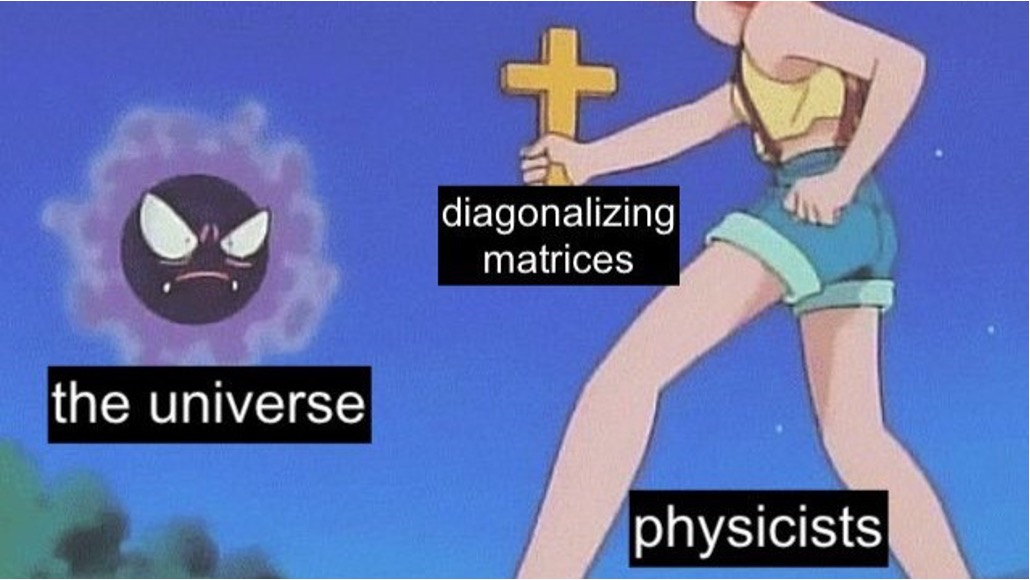